In [1]:
import osmnx as ox
import networkx as nx
import pandas as pd
import numpy as np
import os
import main
import warnings
warnings.simplefilter(action='ignore',category=FutureWarning) 
warnings.simplefilter(action='ignore',category=RuntimeWarning) 
warnings.simplefilter(action='ignore',category=DeprecationWarning)

In [2]:
def check_folders(foldername='Input'):
    if os.path.isdir(foldername):
        try:
            os.rename(foldername,f'{foldername}_CAREFUL_PREVIOUS_INPUT')
        except OSError:
            print('TOO MANY CASES WITH THE SAME NAME')
            raise
    os.makedirs(foldername, exist_ok=True)
    os.makedirs(f'./{foldername}/StatesMatrices', exist_ok=True)

def download_nwk(lat=38.42498,lon=141.29978,radius=1000,show=True, save=True, foldername='Input'):
    G = ox.graph_from_point(center_point=(lat,lon), network_type='all', dist=radius, simplify=True)
    G_proj = ox.project_graph(G)
    G_und = G_proj.to_undirected()
    g_und = nx.Graph(G_und)
    G_und2 = nx.MultiGraph(g_und) 
    fig, ax = ox.plot_graph(G_und2,node_color='blue',bgcolor='white', show=show, save=save,filepath=f'./{foldername}/nwk_simple.png')
    return G_und2


node_ids = {}
def get_nodedb(G,evacnodes=[0],foldername='Input'):
    node_coords = {}
    for i, node in enumerate(G.nodes(data=True)):
        node_ids[i] = node[0]
        node_coords[node[0]] = node[1]['x'],node[1]['y']
    Gdfn = pd.DataFrame(node_coords).T
    Gdfn.columns = ['Coord_x','Coord_y']
    Gdfn.reset_index(inplace=True)
    Gdfn.index = list(node_ids.values())
    Gdfn['#number'] = list(node_ids.keys()) 
    Gdfn['Coord_x'] = Gdfn['Coord_x'].astype(np.float64)
    Gdfn['Coord_y'] = Gdfn['Coord_y'].astype(np.float64) 
    Gdfn = Gdfn[['#number','Coord_x','Coord_y']]
    Gdfn['evacuation'] = 0
    Gdfn['reward'] = 1
    for node in evacnodes:
        Gdfn.loc[Gdfn.index == node,'evacuation'] = 1
    Gdfn.to_csv(f'./{foldername}/nodes.csv',index=False)
    return Gdfn

edge_ids = {}
def get_edgedb(G, foldername='Input'):
    node1 = []
    node2 = []
    length = []
    for j,edge in enumerate(G.edges(data=True)):
        if type(edge[2]['osmid']) is not list:
            osmid = edge[2]['osmid']
        else:
            osmid = edge[2]['osmid'][0]
        edge_ids[j] = osmid
        length.append(edge[2]['length'])
        node1.append(list(node_ids.values()).index(edge[:2][0])) 
        node2.append(list(node_ids.values()).index(edge[:2][1]))
    Gdfe = pd.DataFrame()
    Gdfe.index = list(edge_ids.values())
    Gdfe['#number'] = list(edge_ids.keys())#id
    Gdfe['Node1'] = node1
    Gdfe['Node2'] = node2
    Gdfe['Length'] = length
    Gdfe['Width'] = 3.0
    Gdfe['#number'] = Gdfe['#number'].astype(np.int64) #or np.float64
    Gdfe['Node1'] = Gdfe['Node1'].astype(np.int64)
    Gdfe['Node2'] = Gdfe['Node2'].astype(np.int64)
    Gdfe['Length'] = Gdfe['Length'].astype(np.float64)
    Gdfe = Gdfe.sort_index()
    Gdfe_new = Gdfe.reset_index()
    Gdfe_new['#number'] = Gdfe_new.index.astype(np.float64)
    Gdfe_new = Gdfe_new.drop(columns='index')
    Gdfe_new.to_csv(f'./{foldername}/edges.csv',index=False)
    return Gdfe_new

#need to modify!
#now times agent in one node.
def get_fake_population(times=1,foldername='Input'):
    df = pd.read_csv(f'./{foldername}/nodes.csv')    
    pop = pd.DataFrame()
    pop['#age']=np.zeros(times) #pop['#age']=np.zeros(df.shape[0] * times )
    pop['Gender']=np.zeros(times) #pop['Gender'] = np.zeros(df.shape[0] * times )
    pop['#Hh Type']=np.zeros(times) #pop['Hh Type'] = np.zeros(df.shape[0] * times )
    pop['#Hh Id']=np.zeros(times) #pop['Hh Id'] = np.zeros(df.shape[0] * times )
    pop['Node']=np.random.choice(df["#number"],times) #pop['Node'] = list(df["#number"]) * times
    pop.sort_values(by='Node')
    pop.reset_index()
    pop.to_csv(f'./{foldername}/population.csv', index=False)
    
def get_actionsdb_transitionsdb(foldername='Input'):
    nodesdb = np.loadtxt(f"./{foldername}/nodes.csv", delimiter=',', skiprows=1)
    linksdb = np.loadtxt(f"./{foldername}/edges.csv", delimiter=',', skiprows=1)
    numNodes = nodesdb.shape[0]
    numLinks = linksdb.shape[0]
    
    actionsdb = np.zeros((numNodes, 12), dtype=np.int32)
    transitionsdb = np.zeros((numNodes, 12), dtype=np.int32)
    probdb = np.zeros((numNodes, 12), dtype=np.int32) 
    rewarddb = np.zeros((numNodes, 12), dtype=np.int32) 
    
    for i in range(numNodes):
        actionsdb[i,0] = nodesdb[i,0]
        transitionsdb[i,0] = nodesdb[i,0]
        rewarddb[i,0] = nodesdb[i,0]
        
        if nodesdb[i,3]:
            actionsdb[i,1] = 1
            actionsdb[i,2] = -1
            transitionsdb[i,1] = 1
            transitionsdb[i,2] = actionsdb[i,0]
            rewarddb[i,1] = 1
            rewarddb[i,2] = 0
            continue
            
        tmpLinksdb1 = linksdb[linksdb[:,1] == nodesdb[i,0]]
        tmpLinksdb2 = linksdb[linksdb[:,2] == nodesdb[i,0]]
        numlinks1 = tmpLinksdb1.shape[0]
        numlinks2 = tmpLinksdb2.shape[0]
        
        actionsdb[i,1] = numlinks1 + numlinks2
        transitionsdb[i,1] = numlinks1 + numlinks2
        rewarddb[i,1] = numlinks1 + numlinks2
        
        if numlinks1:
            actionsdb[i, 2: 2+numlinks1] = tmpLinksdb1[:,0]
            transitionsdb[i,2:2 + numlinks1] = tmpLinksdb1[:,2]
            rewarddb[i, 2:2+numlinks1] = -tmpLinksdb1[:,3]
        
        if numlinks2:
            actionsdb[i, 2+numlinks1 : 2+numlinks1+numlinks2] = tmpLinksdb2[:,0]
            transitionsdb[i, 2+numlinks1 : 2+numlinks1+numlinks2] = tmpLinksdb2[:,1]
            rewarddb[i, 2+numlinks1 : 2+numlinks1+numlinks2] = -tmpLinksdb2[:,3]

    ind = np.argmax(actionsdb[:,1])
    probdb[:,0:2] = actionsdb[:,0:2]
#    rewarddb[:,0:2] = actionsdb[:,0:2]
    
    for i in range(numNodes):
        numActions = actionsdb[i,1]
        if numActions:
            probdb[i,2:2+numActions] = np.ones(numActions)
    
    np.savetxt(f'./{foldername}/actionsdb.csv', actionsdb, delimiter=',', fmt='%d')
    np.savetxt(f'./{foldername}/transitionsdb.csv', transitionsdb, delimiter=',', fmt='%d')

In [3]:
areas = {
    'ishinomaki': (38.4259826,141.3012349),  #2166925996
    'otaru' : (43.1908875, 140.9951859),  #1644237911
    'kochi' : (33.5581452, 133.5319937),  #5303394931
    'noto' : (37.3910308,136.9047961),  #11494769981
    'sumatra' : (5.5485879, 95.3137873),  #764419156
    'peru' : (-12.0716443,-77.1622644)  #3042136183
}



 ***** Simu 0 (t= 0.81)*****
epsilon greedy - exploration: 0.990000
survived pedestrians: 326
Checkpoint


 ***** Simu 1 (t= 1.62)*****
epsilon greedy - exploration: 1.000000
survived pedestrians: 298


 ***** Simu 2 (t= 2.40)*****
epsilon greedy - exploration: 0.833333
survived pedestrians: 952


 ***** Simu 3 (t= 3.06)*****
epsilon greedy - exploration: 0.714286
survived pedestrians: 1845


 ***** Simu 4 (t= 3.63)*****
epsilon greedy - exploration: 0.625000
survived pedestrians: 2385


 ***** Simu 5 (t= 4.09)*****
epsilon greedy - exploration: 0.555556
survived pedestrians: 2872


 ***** Simu 6 (t= 4.49)*****
epsilon greedy - exploration: 0.500000
survived pedestrians: 3193


 ***** Simu 7 (t= 4.85)*****
epsilon greedy - exploration: 0.454545
survived pedestrians: 3292


 ***** Simu 8 (t= 5.16)*****
epsilon greedy - exploration: 0.416667
survived pedestrians: 3457


 ***** Simu 9 (t= 5.44)*****
epsilon greedy - exploration: 0.384615
survived pedestrians: 3582


 ***** Simu 10 (t= 5

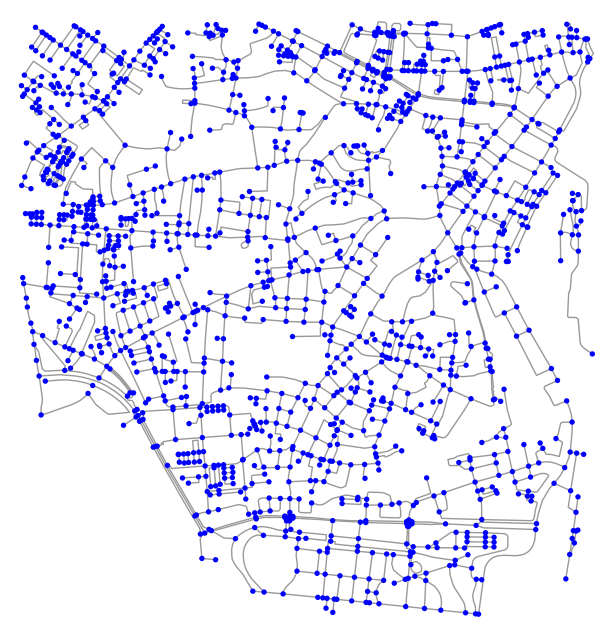

In [6]:
case = 'ishinomaki' #use names in 'areas' dictionary
#prepare folders
check_folders(foldername=case)
#download network
G = download_nwk(areas[case][0],areas[case][1],1000,show=False, save=True, foldername=case)
#set seed for replication
#np.random.seed(10) #---> CAREFUL (When finishing task 1 and 2 turn off this and run several simulations per case. 10 times take average)
#choose randomnly 4 nodes for evacuation
evacnodes = [2166925996] #np.random.choice(G.nodes, size=1) #[461190492] ---> TASK 1
#prepare databases
Gdfn = get_nodedb(G, evacnodes=evacnodes, foldername=case)
Gdfe = get_edgedb(G, foldername=case)
get_fake_population(times=3703,foldername=case)
get_actionsdb_transitionsdb(foldername=case)
#run evacuation model (RL)
main.run(numSim0=0, numBlocks=1, simPerBlock=20, simulTime=40*60, foldername=case) #---> when finish task 1 and 2 change to 40

ValueError: Length mismatch: Expected axis has 1074 elements, new values have 1523 elements

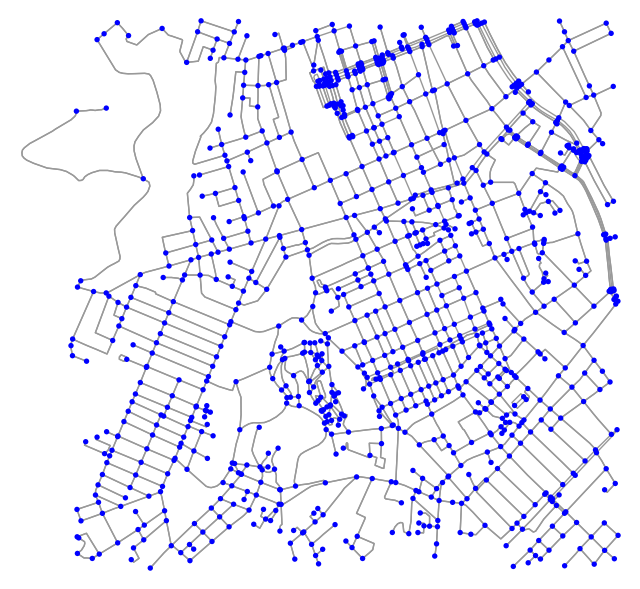

In [5]:
case = 'otaru' #use names in 'areas' dictionary
#prepare folders
check_folders(foldername=case)
#download network
G = download_nwk(areas[case][0],areas[case][1],1000,show=False, save=True, foldername=case)
#set seed for replication
#np.random.seed(10) #---> CAREFUL (When finishing task 1 and 2 turn off this and run several simulations per case. 10 times take average)
#choose randomnly 4 nodes for evacuation
evacnodes = [1644237911] #np.random.choice(G.nodes, size=1) #[461190492] ---> TASK 1
#prepare databases
Gdfn = get_nodedb(G, evacnodes=evacnodes, foldername=case)
Gdfe = get_edgedb(G, foldername=case)
get_fake_population(times=10000, foldername=case) #----> TASK 2
get_actionsdb_transitionsdb(foldername=case)
#run evacuation model (RL)
main.run(numSim0=0, numBlocks=1, simPerBlock=20, simulTime=40*60, foldername=case) #---> when finish task 1 and 2 change to 40

ValueError: could not broadcast input array from shape (6,) into shape (4,)

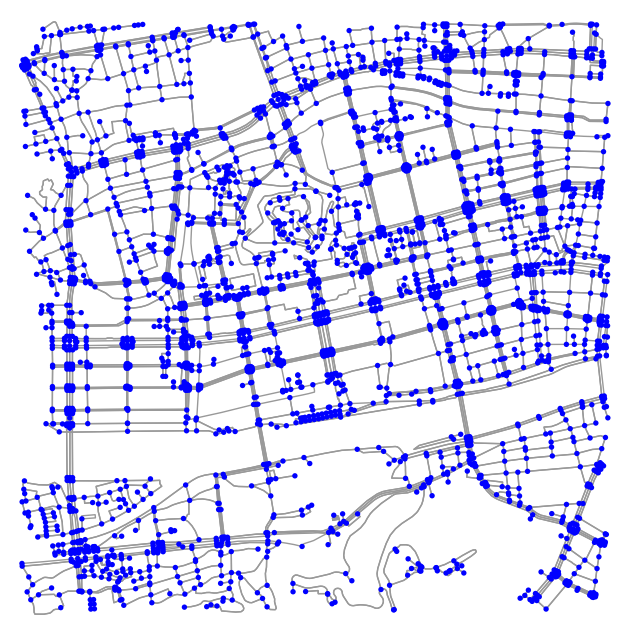

In [6]:
case = 'kochi' #use names in 'areas' dictionary
#prepare folders
check_folders(foldername=case)
#download network
G = download_nwk(areas[case][0],areas[case][1],1000,show=False, save=True, foldername=case)
#set seed for replication
#np.random.seed(10) #---> CAREFUL (When finishing task 1 and 2 turn off this and run several simulations per case. 10 times take average)
#choose randomnly 4 nodes for evacuation
evacnodes = [5303394931] #np.random.choice(G.nodes, size=1) #[461190492] ---> TASK 1
#prepare databases
Gdfn = get_nodedb(G, evacnodes=evacnodes, foldername=case)
Gdfe = get_edgedb(G, foldername=case)
get_fake_population(times=10000, foldername=case) #----> TASK 2
get_actionsdb_transitionsdb(foldername=case)
#run evacuation model (RL)
main.run(numSim0=0, numBlocks=1, simPerBlock=20, simulTime=40*60, foldername=case) #---> when finish task 1 and 2 change to 40

ValueError: Length mismatch: Expected axis has 1049 elements, new values have 1523 elements

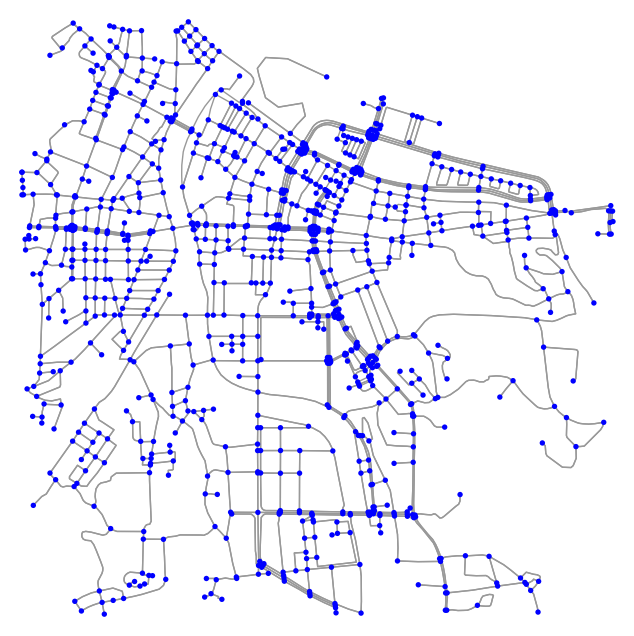

In [15]:
case = 'noto' #use names in 'areas' dictionary
#prepare folders
check_folders(foldername=case)
#download network
G = download_nwk(areas[case][0],areas[case][1],1000,show=False, save=True, foldername=case)
#set seed for replication
#np.random.seed(10) #---> CAREFUL (When finishing task 1 and 2 turn off this and run several simulations per case. 10 times take average)
#choose randomnly 4 nodes for evacuation
evacnodes = [11494769981] #np.random.choice(G.nodes, size=1) #[461190492] ---> TASK 1
#prepare databases
Gdfn = get_nodedb(G, evacnodes=evacnodes, foldername=case)
Gdfe = get_edgedb(G, foldername=case)
get_fake_population(times=10000, foldername=case) #----> TASK 2
get_actionsdb_transitionsdb(foldername=case)
#run evacuation model (RL)
main.run(numSim0=0, numBlocks=1, simPerBlock=20, simulTime=40*60, foldername=case) #---> when finish task 1 and 2 change to 40

ValueError: Length mismatch: Expected axis has 1184 elements, new values have 3258 elements

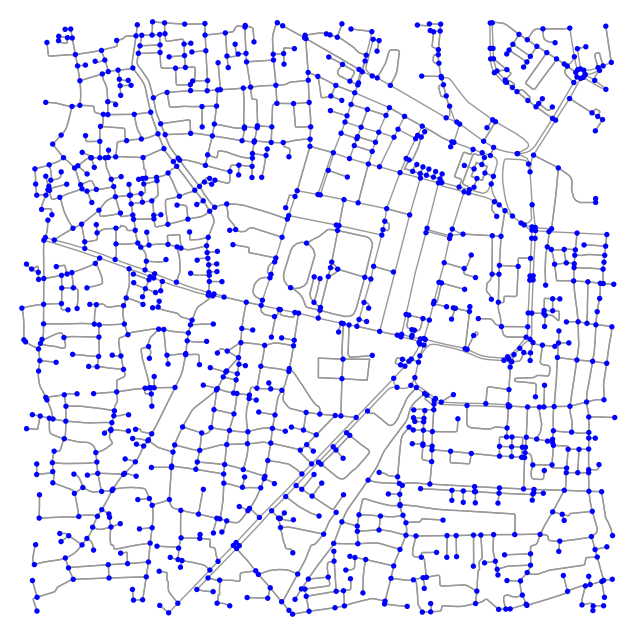

In [9]:
case = 'sumatra' #use names in 'areas' dictionary
#prepare folders
check_folders(foldername=case)
#download network
G = download_nwk(areas[case][0],areas[case][1],1000,show=False, save=True, foldername=case)
#set seed for replication
#np.random.seed(10) #---> CAREFUL (When finishing task 1 and 2 turn off this and run several simulations per case. 10 times take average)
#choose randomnly 4 nodes for evacuation
evacnodes = [764419156] #np.random.choice(G.nodes, size=1) #[461190492] ---> TASK 1
#prepare databases
Gdfn = get_nodedb(G, evacnodes=evacnodes, foldername=case)
Gdfe = get_edgedb(G, foldername=case)
get_fake_population(times=10000, foldername=case) #----> TASK 2
get_actionsdb_transitionsdb(foldername=case)
#run evacuation model (RL)
main.run(numSim0=0, numBlocks=1, simPerBlock=20, simulTime=40*60, foldername=case) #---> when finish task 1 and 2 change to 40

ValueError: Length mismatch: Expected axis has 2179 elements, new values have 3258 elements

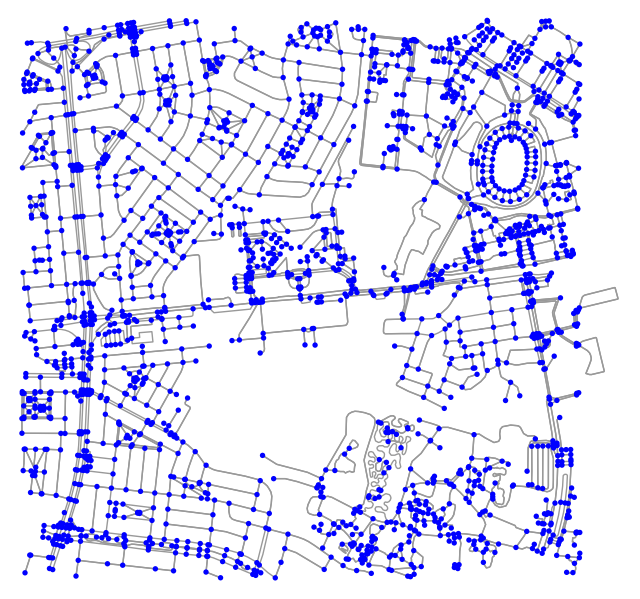

In [10]:
case = 'peru' #use names in 'areas' dictionary
#prepare folders
check_folders(foldername=case)
#download network
G = download_nwk(areas[case][0],areas[case][1],1000,show=False, save=True, foldername=case)
#set seed for replication
#np.random.seed(10) #---> CAREFUL (When finishing task 1 and 2 turn off this and run several simulations per case. 10 times take average)
#choose randomnly 4 nodes for evacuation
evacnodes = [1451644688] #np.random.choice(G.nodes, size=1) #[461190492] ---> TASK 1
#prepare databases
Gdfn = get_nodedb(G, evacnodes=evacnodes, foldername=case)
Gdfe = get_edgedb(G, foldername=case)
get_fake_population(times=10000, foldername=case) #----> TASK 2
get_actionsdb_transitionsdb(foldername=case)
#run evacuation model (RL)
main.run(numSim0=0, numBlocks=1, simPerBlock=20, simulTime=40*60, foldername=case) #---> when finish task 1 and 2 change to 40

In [14]:
df = pd.read_csv("./ishinomaki/population.csv")


In [15]:
import pandas as pd
df = pd.read_csv("./ishinomaki/nodes.csv")

In [16]:
df[df["evacuation"] == 1]

,#number,Coord_x,Coord_y,evacuation,reward
387,387,526293.92901,4.253123e+06,1,1


In [17]:
G.graph["crs"]

<Projected CRS: EPSG:32654>
Name: WGS 84 / UTM zone 54N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 138°E and 144°E, northern hemisphere between equator and 84°N, onshore and offshore. Japan. Russian Federation.
- bounds: (138.0, 0.0, 144.0, 84.0)
Coordinate Operation:
- name: UTM zone 54N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [18]:
G.nodes(data=True)

NodeDataView({461190492: {'y': 4254096.328888247, 'x': 526533.1108533128, 'street_count': 3, 'lon': 141.3040118, 'lat': 38.4347441}, 918333243: {'y': 4254088.457631121, 'x': 526531.8800151877, 'street_count': 4, 'lon': 141.3039974, 'lat': 38.4346732}, 461190495: {'y': 4253944.728143291, 'x': 526508.1427625108, 'street_count': 4, 'highway': 'traffic_signals', 'lon': 141.30372, 'lat': 38.4333786}, 2166919145: {'y': 4253948.112982299, 'x': 526501.5594760083, 'street_count': 4, 'highway': 'crossing', 'lon': 141.3036447, 'lat': 38.4334093}, 2166919097: {'y': 4253938.474846171, 'x': 526519.7453480982, 'street_count': 4, 'highway': 'crossing', 'lon': 141.3038527, 'lat': 38.4333219}, 2163643372: {'y': 4253967.397036149, 'x': 526511.3235770497, 'street_count': 3, 'lon': 141.3037573, 'lat': 38.4335828}, 2166919138: {'y': 4253935.849220758, 'x': 526507.5436073428, 'street_count': 4, 'highway': 'crossing', 'lon': 141.3037128, 'lat': 38.4332986}, 461192779: {'y': 4254093.285326951, 'x': 526213.9898

In [19]:
Gdfn.head()

,#number,Coord_x,Coord_y,evacuation,reward
461190492,0,526533.110853,4.254096e+06,0,1
918333243,1,526531.880015,4.254088e+06,0,1
461190495,2,526508.142763,4.253945e+06,0,1
2166919145,3,526501.559476,4.253948e+06,0,1
2166919097,4,526519.745348,4.253938e+06,0,1


In [20]:
g = ox.convert.to_digraph(G)

In [21]:
g

TypeError: OutEdgeView.__call__() got an unexpected keyword argument 'keys'

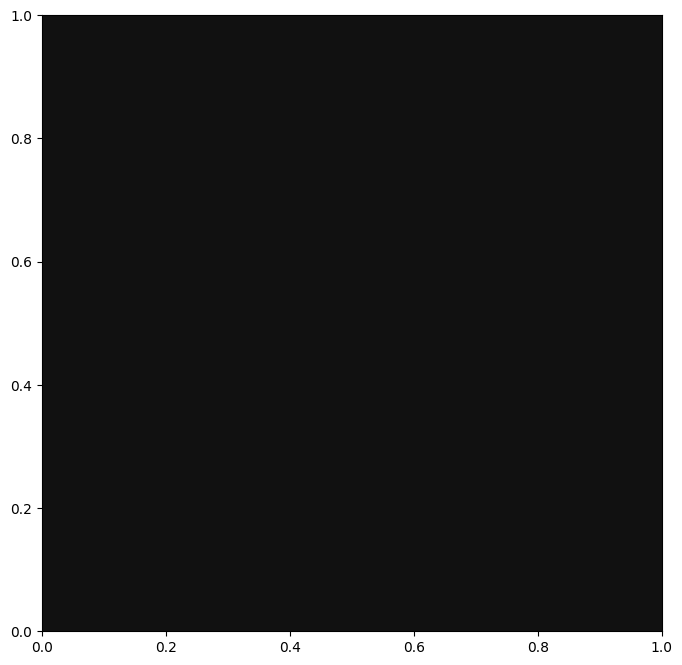

In [22]:
ox.plot_graph(g)